In [38]:
import numpy as np
import matplotlib.pyplot as plt
import time
import math

from numba import cuda

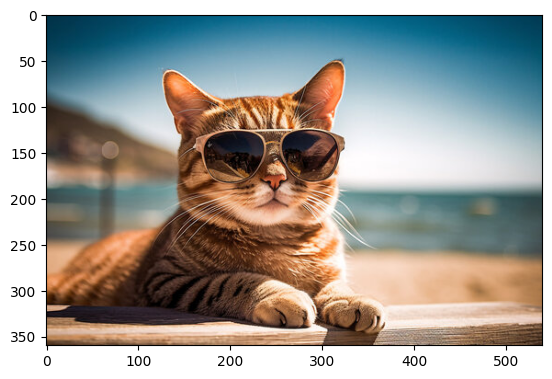

In [39]:
img = plt.imread('cat.jpg')

plt.imshow(img)

In [40]:
gauss = np.array([
    [0,0,1,2,1,0,0],
    [0,3,13,22,13,3,0],
    [1,13,59,97,59,13,1],
    [2,22,97,159,97,22,2],
    [1,13,59,97,59,13,1],
    [0,3,13,22,13,3,0],
    [0,0,1,2,1,0,0]
], dtype=np.float32)

In [41]:
height, width = img.shape[:2]

In [52]:
blockSize = (16,16)

gridSize = (
    (width  + blockSize[0] - 1) // blockSize[0],
    (height + blockSize[1] - 1) // blockSize[1])

##Without shared memory

In [42]:
@cuda.jit
def gaussian(src, dst, kernel):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

  for c in range(3):

    sum = 0.0

    for ky in range(-3, 4):
        for kx in range(-3, 4):

            nx = min(max(tidx + kx, 0), width - 1)
            ny = min(max(tidy + ky, 0), height - 1)

            sum += src[ny, nx, c] * kernel[ky + 3, kx + 3]

    dst[tidy, tidx, c] = np.uint8(sum / 1003.0)


In [43]:
devSrc = cuda.to_device(img)

devDst = cuda.device_array(img.shape, dtype=np.uint8)

devKernel = cuda.to_device(gauss)

In [50]:
start = time.time()
gaussian[gridSize, blockSize](devSrc, devDst, devKernel)
cuda.synchronize()
elapsed_without = time.time() - start

GPU time: 0.1781768798828125


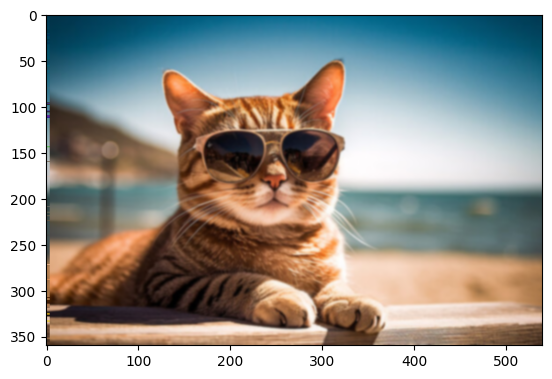

In [45]:
print("GPU time:", elapsed_without)
hostDst = devDst.copy_to_host()
plt.imshow(hostDst)
plt.show()

##With shared memory

In [46]:
@cuda.jit
def gaussian_shared(src, dst, kernel):

    tile = cuda.shared.array((7,7), dtype=np.float32)

    tx = cuda.threadIdx.x
    ty = cuda.threadIdx.y

    if tx < 7 and ty < 7:
        tile[ty, tx] = kernel[ty, tx]

    cuda.syncthreads()

    tidx = tx + cuda.blockIdx.x * cuda.blockDim.x
    tidy = ty + cuda.blockIdx.y * cuda.blockDim.y
    for c in range(3):
        sum = 0.0

        for ky in range(-3, 4):
            for kx in range(-3, 4):

                nx = min(max(tidx + kx, 0), src.shape[1] - 1)
                ny = min(max(tidy + ky, 0), src.shape[0] - 1)

                sum += (src[ny, nx, c]* tile[ky + 3, kx + 3])

        dst[tidy, tidx, c] = np.uint8(sum / 1003.0)

In [47]:
devSrc = cuda.to_device(img)

devDst = cuda.device_array(img.shape, dtype=np.uint8)

devKernel = cuda.to_device(gauss)

In [53]:
start = time.time()
gaussian_shared[gridSize, blockSize](devSrc, devDst, devKernel)
cuda.synchronize()
elapsed_with = time.time() - start

GPU time: 0.002073526382446289


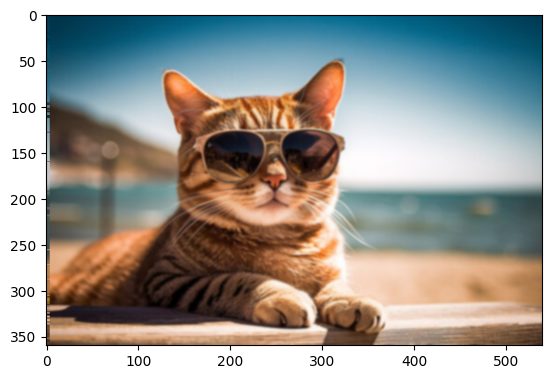

In [54]:
print("GPU time:", elapsed_with)
hostDst = devDst.copy_to_host()
plt.imshow(hostDst)
plt.show()

In [62]:
block_sizes = [(8, 8), (16, 16), (32, 8), (32, 16),(32, 32)]

times_without = []
times_with = []

for blockSize in block_sizes:
    gridSize = (
        (width + blockSize[0] - 1) // blockSize[0],
        (height + blockSize[1] - 1) // blockSize[1])

    #Without shared memory
    devDst = cuda.device_array(img.shape, dtype=np.uint8)
    gaussian[gridSize, blockSize](devSrc, devDst, devKernel)
    cuda.synchronize()

    start = time.time()
    gaussian[gridSize, blockSize](devSrc, devDst, devKernel)

    cuda.synchronize()

    elapsed_without = time.time() - start
    times_without.append(elapsed_without)

    #With shared memory
    devDst = cuda.device_array(img.shape, dtype=np.uint8)
    gaussian_shared[gridSize, blockSize](devSrc, devDst, devKernel)
    cuda.synchronize()

    start = time.time()
    gaussian_shared[gridSize, blockSize](devSrc, devDst, devKernel)

    cuda.synchronize()

    elapsed_with = time.time() - start
    times_with.append(elapsed_with)

    print("Block size:", blockSize,"| Without:", elapsed_without,"| With:", elapsed_with)

Block size: (8, 8) | Without: 0.0017311573028564453 | With: 0.00160980224609375
Block size: (16, 16) | Without: 0.0016818046569824219 | With: 0.00164031982421875
Block size: (32, 8) | Without: 0.00165557861328125 | With: 0.001657247543334961
Block size: (32, 16) | Without: 0.0016489028930664062 | With: 0.0016486644744873047
Block size: (32, 32) | Without: 0.0019714832305908203 | With: 0.0019958019256591797


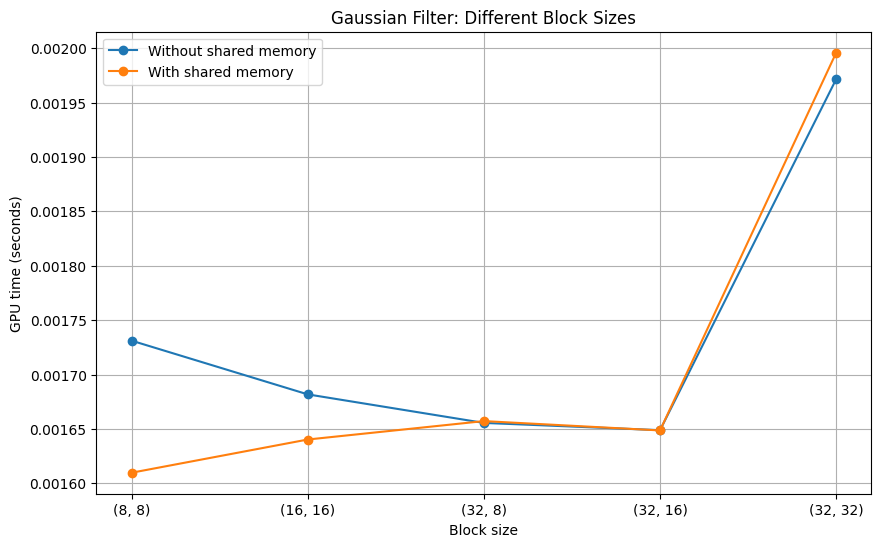

In [63]:
plt.figure(figsize=(10, 6))

plt.plot([str(b) for b in block_sizes], times_without, marker="o", label="Without shared memory")

plt.plot([str(b) for b in block_sizes], times_with, marker="o", label="With shared memory")

plt.xlabel("Block size")
plt.ylabel("GPU time (seconds)")
plt.title("Gaussian Filter: Different Block Sizes")

plt.legend()
plt.grid(True)
plt.show()